## Load Libraries

In [1]:
# Add package to path and imports
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

base_dir = get_base_dir()

# Plotting defaults (match compare_mass_functions style)
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

xi(~0.88 Mpc) = 15.5
xi(~4.97 Mpc) = 0.169
xi(~8.87 Mpc) = -0.000283


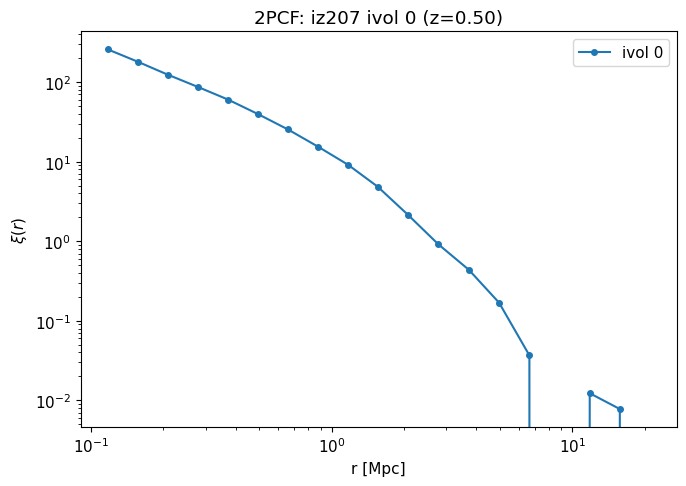

In [2]:
# Correlation for a given snapshot and subvolume
from galform_analysis.analysis.correlation import correlation_given_redshift_and_subvolume

example_snapshot = 'iz207'
example_ivol = 0

snap_path = str(base_dir / example_snapshot)
res = correlation_given_redshift_and_subvolume(snap_path, example_ivol, nthreads=4)

if res is None:
    print("No valid correlation data for this (snapshot, ivol). Try another ivol or snapshot.")
else:
    r = res['r']
    xi = res['xi']
    z_val = res.get('z')
    L = res.get('boxsize')
    ngal = res.get('ngal')

    fig, ax = plt.subplots(figsize=(7,5))
    ax.loglog(r, xi, 'o-', label=f'ivol {example_ivol}', ms=4)
    ax.set_xlabel('r [Mpc]')
    ax.set_ylabel(r'$\xi(r)$')
    title = f"2PCF: {example_snapshot} ivol {example_ivol}"
    if z_val is not None:
        title += f" (z={z_val:.2f})"
    ax.set_title(title)
    ax.legend()
    
    for r_target in [1.0, 5.0, 10.0]:
        if (r.size > 0):
            i = np.argmin(np.abs(r - r_target))
            print(f"xi(~{r[i]:.2f} Mpc) = {xi[i]:.3g}")

    plt.tight_layout()
    plt.show()


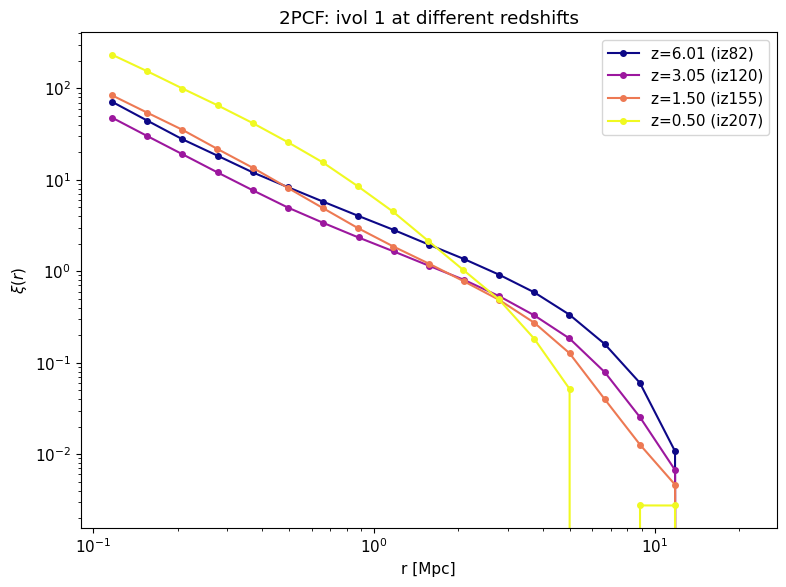

In [3]:
# Correlation for one subvolume across multiple redshifts (overlay)
from galform_analysis.analysis.correlation import correlation_given_redshift_and_subvolume

example_ivol = 1
iz_nums = [82, 120, 155, 207]

fig, ax = plt.subplots(figsize=(8,6))
colors = plt.cm.plasma(np.linspace(0, 1, len(iz_nums)))

for iz, c in zip(iz_nums, colors):
    snap = f'iz{iz}'
    res = correlation_given_redshift_and_subvolume(str(base_dir / snap), example_ivol, nthreads=4)
    if res is None:
        print(f"Skipping {snap}: correlation unavailable")
        continue

    r = res['r']
    xi = res['xi']
    label = f"z={res['z']:.2f} ({snap})" if res.get('z') is not None else snap
    ax.loglog(r, xi, 'o-', color=c, label=label, ms=4)

ax.set_xlabel('r [Mpc]')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title(f"2PCF: ivol {example_ivol} at different redshifts")
ax.legend()
plt.tight_layout()
plt.show()


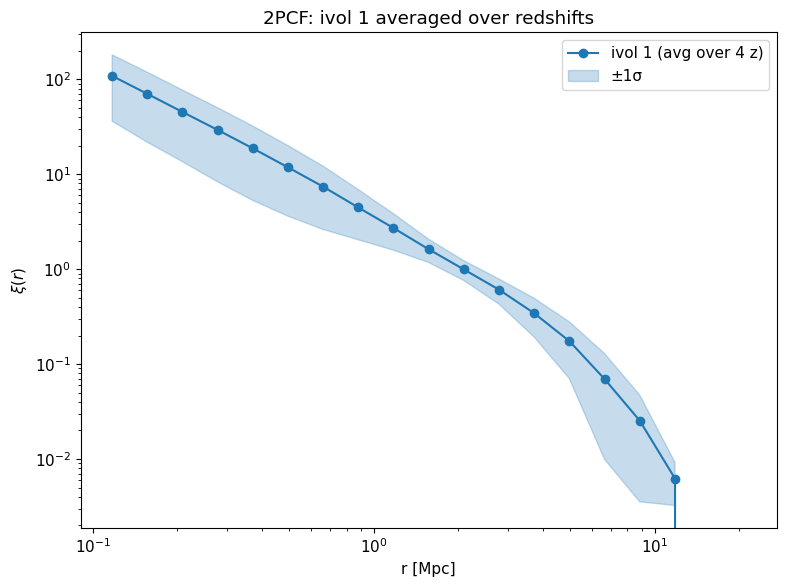

In [4]:
# Average correlation over multiple redshifts for one subvolume
from galform_analysis.analysis.correlation import correlation_given_redshift_and_subvolume

example_ivol = 1
iz_nums = [82, 120, 155, 207]

results = []
for iz in iz_nums:
    snap = f'iz{iz}'
    res = correlation_given_redshift_and_subvolume(str(base_dir / snap), example_ivol, nthreads=4)
    if res is None:
        print(f"Skipping {snap}: correlation unavailable")
        continue
    results.append(res)

if not results:
    print("No correlation results available to average.")
else:
    # Check that all r grids have the same length
    r_lengths = [len(r_['r']) for r_ in results]
    if len(set(r_lengths)) > 1:
        print(f"Warning: Different r grid lengths: {r_lengths}")
        # Use the minimum length to ensure compatibility
        min_len = min(r_lengths)
        r = results[0]['r'][:min_len]
        xis = np.vstack([r_['xi'][:min_len] for r_ in results])
    else:
        # All grids have same length, use first as reference
        r = results[0]['r']
        xis = np.vstack([r_['xi'] for r_ in results])
    
    xi_mean = np.mean(xis, axis=0)
    xi_std = np.std(xis, axis=0)

    fig, ax = plt.subplots(figsize=(8,6))
    ax.loglog(r, xi_mean, 'o-', color='C0', label=f'ivol {example_ivol} (avg over {len(results)} z)')
    ax.fill_between(r, xi_mean - xi_std, xi_mean + xi_std, color='C0', alpha=0.25, label='±1σ')
    ax.set_xlabel('r [Mpc]')
    ax.set_ylabel(r'$\xi(r)$')
    ax.set_title(f"2PCF: ivol {example_ivol} averaged over redshifts")
    ax.legend()
    plt.tight_layout()
    plt.show()
